# Chapter 06 — The Price of Intelligence

**Companion to *Applied AI*.**

This notebook accompanies Chapter 6. The chapter's arithmetic is short enough
to do in your head and almost nobody does it. Here it is, runnable.

## Question

**When does the cheapest model bill produce the most expensive process?**

## What this notebook establishes

- The chapter's invoice, reproduced exactly: a review costing a quarter of a
  cent becomes roughly $453,600 a year, and **a cheaper model divides that by a
  constant while leaving the shape alone**.
- The chapter's three-row cascade table, reproduced exactly, including the arm
  with the lowest model bill and the highest process cost.
- A sweep that finds the exact acceptance rate at which a weak check stops
  saving money — a number the chapter does not print.

## What this notebook does **not** establish

- **Every price here is illustrative**, taken from the chapter, which labels
  them as illustrations rather than quotes. No provider is being priced.
- The acceptance and wrongness rates in the cascade are **invented for
  teaching**. The structure is the lesson, not the numbers.
- The external results the chapter cites — FrugalGPT, RouteLLM, distillation
  ratios, Epoch's price decline — are **not** reproduced here.
- Chapter 28 contains this book's one *measured* cost result. It is reproduced
  in the Chapter 08 and Chapter 28 notebooks, not this one.

## Setup

In [1]:
import matplotlib.pyplot as plt

## 1. The invoice nobody runs at prototype time

The chapter's five factors, with its own illustrative prices.

In [2]:
tokens_in, tokens_out = 1_200, 400        # one paragraph review
paragraphs, edits_per_paragraph = 3_000, 4.5
users, months = 1_000, 12
price_in, price_out = 1.00, 4.00          # $ per million tokens: illustrative

reviews = paragraphs * edits_per_paragraph * users * months
annual = reviews * (tokens_in * price_in + tokens_out * price_out) / 1e6
per_review = (tokens_in * price_in + tokens_out * price_out) / 1e6

print(f"cost of one review : ${per_review:.6f}   (about a quarter of a cent)")
print(f"reviews per year   : {reviews:,.0f}")
print(f"annual bill        : ${annual:,.0f}")

assert abs(annual - 453_600) < 1, "should reproduce the chapter's figure"
print()
print("assertion held: reproduces the chapter's $453,600")

cost of one review : $0.002800   (about a quarter of a cent)
reviews per year   : 162,000,000
annual bill        : $453,600

assertion held: reproduces the chapter's $453,600


## Coefficient versus shape

The chapter's central distinction. A ten-times-cheaper model divides the total
by ten. It is still a product of five factors, four of which grow with success,
billed every month for as long as the product runs.

In [3]:
def invoice(price_scale=1.0, users=1_000, months=12, edits=4.5, paragraphs=3_000):
    r = paragraphs * edits * users * months
    return r * (tokens_in * price_in + tokens_out * price_out) * price_scale / 1e6

print(f"{'change':<44}{'annual bill':>16}   {'what moved'}")
print("-" * 92)
print(f"{'baseline':<44}${invoice():>15,.0f}   -")
print(f"{'model 10x cheaper':<44}${invoice(price_scale=0.1):>15,.0f}   the coefficient")
print(f"{'model 100x cheaper':<44}${invoice(price_scale=0.01):>15,.0f}   the coefficient")
print(f"{'10x cheaper AND 10x the users':<44}"
      f"${invoice(price_scale=0.1, users=10_000):>15,.0f}   coefficient down, shape up")
print(f"{'operation moved to deterministic code':<44}${0:>15,.0f}   the SHAPE")

change                                           annual bill   what moved
--------------------------------------------------------------------------------------------
baseline                                    $        453,600   -
model 10x cheaper                           $         45,360   the coefficient
model 100x cheaper                          $          4,536   the coefficient
10x cheaper AND 10x the users               $        453,600   coefficient down, shape up
operation moved to deterministic code       $              0   the SHAPE


> **A cheaper model changes the coefficient. Only an architectural change
> alters the shape.**

The last row is the chapter's ratchet arriving at its most permanent rung:
moving the operation to the deterministic side removes the inference cost
entirely and leaves ordinary code upkeep.

## 2. The cascade: the unit is the verified outcome

The chapter's worked example. Ten thousand items go either straight to a
frontier model, or first to a small model behind a check. Whatever the frontier
model does not settle goes to a person.

Every price and rate below is **invented for teaching**.

In [4]:
N = 10_000                                   # items
SMALL, FRONTIER = 0.001, 0.01                # $ per attempt
PERSON, REWORK = 5.00, 20.00                 # $ per escalation, $ per wrong answer found later

def run(first_small, small_accept, small_wrong,
        frontier_accept=0.96, frontier_wrong=0.005):
    model = wrong = 0.0
    to_frontier = N
    if first_small:
        model += N * SMALL
        accepted_small = N * small_accept
        wrong += accepted_small * small_wrong
        to_frontier = N - accepted_small
    model += to_frontier * FRONTIER
    accepted_frontier = to_frontier * frontier_accept
    wrong += accepted_frontier * frontier_wrong
    people = (to_frontier - accepted_frontier) * PERSON
    total = model + people + wrong * REWORK
    return model, people, wrong, total, total / (N - wrong)

arms = {
    "frontier first":          run(False, 0, 0),
    "cascade, adequate check": run(True, 0.80, 0.002),
    "cascade, weak check":     run(True, 0.90, 0.030),
}

print(f"{'arm':<26}{'model':>10}{'people':>10}{'wrong':>9}"
      f"{'total':>12}{'per verified outcome':>23}")
print("-" * 92)
for name, (model, people, wrong, total, per) in arms.items():
    print(f"{name:<26}${model:>9,.0f}${people:>9,.0f}{wrong:>9,.0f}"
          f"${total:>11,.0f}{'$' + format(per, '.3f'):>23}")

arm                            model    people    wrong       total   per verified outcome
--------------------------------------------------------------------------------------------
frontier first            $      100$    2,000       48$      3,060                 $0.307
cascade, adequate check   $       30$      400       26$        942                 $0.094
cascade, weak check       $       20$      200      275$      5,716                 $0.588


## Observation

Read the three rows slowly, because the ordering of the columns disagrees.

In [5]:
model_bill = {k: v[0] for k, v in arms.items()}
total_cost = {k: v[3] for k, v in arms.items()}
per_out    = {k: v[4] for k, v in arms.items()}

def rank(d, label):
    order = sorted(d, key=d.get)
    print(f"{label:<34}" + "  <  ".join(order))

rank(model_bill, "cheapest MODEL BILL first:")
rank(total_cost, "cheapest TOTAL PROCESS first:")
rank(per_out,    "cheapest PER VERIFIED OUTCOME first:")
print()
best_bill = min(model_bill, key=model_bill.get)
worst_real = max(per_out, key=per_out.get)
print(f"The arm with the lowest model bill is: {best_bill!r}")
print(f"The most expensive arm per verified outcome is: {worst_real!r}")
assert best_bill == worst_real == "cascade, weak check"
print()
print("assertion held: the same arm wins the dashboard and loses the only")
print("unit that matters.")

cheapest MODEL BILL first:        cascade, weak check  <  cascade, adequate check  <  frontier first
cheapest TOTAL PROCESS first:     cascade, adequate check  <  frontier first  <  cascade, weak check
cheapest PER VERIFIED OUTCOME first:cascade, adequate check  <  frontier first  <  cascade, weak check

The arm with the lowest model bill is: 'cascade, weak check'
The most expensive arm per verified outcome is: 'cascade, weak check'

assertion held: the same arm wins the dashboard and loses the only
unit that matters.


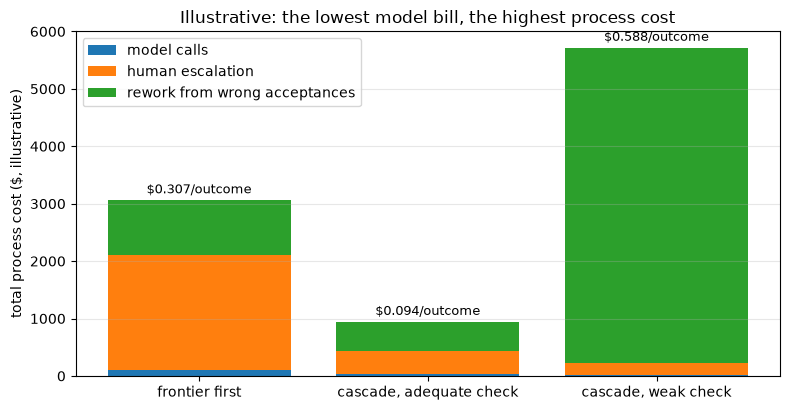

Prices and rates are invented for teaching, as in the chapter.


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
names = list(arms)
models  = [arms[n][0] for n in names]
peoples = [arms[n][1] for n in names]
reworks = [arms[n][2] * REWORK for n in names]

ax.bar(names, models, label="model calls")
ax.bar(names, peoples, bottom=models, label="human escalation")
ax.bar(names, reworks, bottom=[m + p for m, p in zip(models, peoples)],
       label="rework from wrong acceptances")
for i, n in enumerate(names):
    ax.text(i, arms[n][3] + 120, f"${arms[n][4]:.3f}/outcome",
            ha="center", fontsize=9)
ax.set_ylabel("total process cost ($, illustrative)")
ax.set_title("Illustrative: the lowest model bill, the highest process cost")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("Prices and rates are invented for teaching, as in the chapter.")

## 3. Where does the weak check stop paying?

The chapter states the rule — *a cascade with a weak acceptance check is a
machine for confidently stopping too early* — but does not print the crossover.
Here it is.

Hold the small model's acceptance rate at 90% and vary how often the answers it
accepts are wrong.

In [7]:
baseline_per_outcome = arms["frontier first"][4]

rates, pers = [], []
crossover = None
for i in range(0, 61):
    w = i / 1000                      # 0.0% .. 6.0% wrong
    per = run(True, 0.90, w)[4]
    rates.append(w)
    pers.append(per)
    if crossover is None and per > baseline_per_outcome:
        crossover = w

print(f"frontier-first cost per verified outcome : ${baseline_per_outcome:.3f}")
print(f"cascade at 0.0% wrong                    : ${run(True, 0.90, 0.0)[4]:.3f}")
print(f"cascade at 3.0% wrong                    : ${run(True, 0.90, 0.03)[4]:.3f}")
print()
print(f"crossover: the cascade becomes MORE expensive per verified outcome")
print(f"once its accepted answers are wrong more than {crossover:.1%} of the time.")

frontier-first cost per verified outcome : $0.307
cascade at 0.0% wrong                    : $0.032
cascade at 3.0% wrong                    : $0.588

crossover: the cascade becomes MORE expensive per verified outcome
once its accepted answers are wrong more than 1.6% of the time.


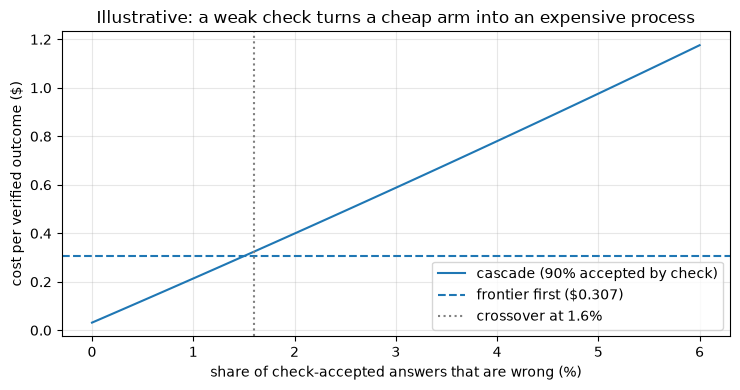

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot([r * 100 for r in rates], pers, label="cascade (90% accepted by check)")
ax.axhline(baseline_per_outcome, linestyle="--",
           label=f"frontier first (${baseline_per_outcome:.3f})")
ax.axvline(crossover * 100, color="grey", linestyle=":",
           label=f"crossover at {crossover:.1%}")
ax.set_xlabel("share of check-accepted answers that are wrong (%)")
ax.set_ylabel("cost per verified outcome ($)")
ax.set_title("Illustrative: a weak check turns a cheap arm into an expensive process")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

Three things follow, and the chapter states all three.

1. **The unit is the verified outcome.** Cost per call ranks these arms in the
   wrong order. Cost per verified outcome — with people and rework in the total
   — ranks them correctly.
2. **Count accepted-but-wrong outcomes separately.** They are the term that
   moves the ordering, and they are invisible on a model-spend dashboard.
3. **A cheaper model changes the coefficient; conversion changes the shape.**
   The ratchet — trim, cheaper model, cascade, route, distil, deterministic —
   is ordered by permanence, not by maturity.

The honest limit, from the chapter: **cost per verified outcome is only as
honest as the check.** A weak check inflates the accepted count and flatters
the cheap path, which is precisely what row three is doing. Chapter 21 shows a
real, well-built check accepting a grounded and wrong answer; Chapter 28
reports the measured ladder that failed its adoption rule for exactly that
reason.

## Try it yourself

1. **Set `REWORK = 0`.** Now the weak cascade wins on every column. Which
   business does that describe, and is it yours?
2. **Make the person free** (`PERSON = 0`) and re-rank. Human escalation
   dominates both totals at $5; at $0 the model bill is the whole story. This
   is why the chapter insists that a cost result names its scenario.
3. **Change the invoice's growth factors** rather than its price: 10× users,
   or twice the edits per paragraph. Compare with a 10× price cut. Only one of
   them is under your control next year.
4. **Add a fourth arm**: a deterministic rule that resolves 25% of items for
   free before either model sees them. Chapter 28 measures a real one that
   resolved 10 of 40 items with no model call.